In [1]:
import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

Read annotation file 

In [2]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [3]:
# Paths to load 
generated_csvs_paths = {"EryPro": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus/filtered/filtered_candidates_EryPro_with_cell_count_pred.csv", 
                        "MgkPro": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus/filtered/filtered_candidates_late_MgkPro_with_cell_count_pred.csv"}

In [4]:
# def conversion(df, conversion_type: str = "buty_to_tpo"):  
#     df_converted = df.copy()
#     if conversion_type == "buty_to_tpo":
#         df_converted["tpo_[ng_ml]"] = df_converted["butyzamide_[nm]"] * 0.025
#         df_converted["butyzamide_[nm]"] = 0
#     elif conversion_type == "tpo_to_buty":
#         df_converted["butyzamide_[nm]"] = df_converted["tpo_[ng_ml]"] * 40
#         df_converted["tpo_[ng_ml]"] = 0
#     else:
#         raise NotImplementedError
#     return df_converted

def conversion(df, conversion_type: str = "buty_to_tpo"):  
    df_converted = df.copy()
    if conversion_type == "buty_to_tpo":
        df_converted["tpo_[ng_ml]"] = df_converted["butyzamide_[nm]"] * 18.87
        df_converted["butyzamide_[nm]"] = 0
    elif conversion_type == "tpo_to_buty":
        df_converted["butyzamide_[nm]"] = df_converted["tpo_[ng_ml]"] * 0.053
        df_converted["tpo_[ng_ml]"] = 0
    else:
        raise NotImplementedError
    return df_converted

In [5]:
generated_csvs = {}

for cell_type in generated_csvs_paths:
    generated_csvs[cell_type] = pd.read_csv(generated_csvs_paths[cell_type], index_col=0) 

In [6]:
generated_csvs["EryPro"]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,uncertainty_loss,target_ct_loss_mean,uncertainty_total_variance_ct,exploitation_score,exploration_score,weighted_uncertainty_score,metric_response_surface,EryPro_prop,filtering_step,density
40,10.059914,2.365526,386.818850,2.246119,0.001872,0.000000,0.000000,0.311756,0.0,0.445375,...,0.016010,0.078949,0.001808,0.000000,0.656299,0.244893,0.328150,0.208978,pass,255279.269100
39,10.430151,2.737875,234.974260,0.801085,0.000000,1.329255,0.000000,0.000000,0.0,0.000000,...,0.025621,0.222485,0.001722,0.017845,0.706450,0.223127,0.362148,0.227803,pass,394736.116481
91,9.154838,2.152026,262.338200,0.802294,0.026731,1.380838,0.000000,0.509927,0.0,0.198715,...,0.025809,0.128758,0.001483,0.003081,0.732001,0.224070,0.367541,0.219454,pass,285942.932930
84,9.104067,2.380117,513.973940,4.597805,0.136655,0.000000,0.000000,0.000000,0.0,0.088945,...,0.026459,0.195037,0.001307,0.014513,0.495308,0.229153,0.254910,0.208052,pass,244102.776089
46,9.804948,2.591037,423.218500,2.064151,0.033131,0.212705,0.000000,0.672123,0.0,0.000000,...,0.026606,0.094521,0.001277,0.000077,0.682240,0.164938,0.341158,0.205749,pass,229584.389965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,10.176407,2.415321,49.429466,0.000000,0.000000,39.363102,0.038267,0.481953,0.0,0.031791,...,0.254970,0.591027,0.001570,0.085001,0.958639,0.060657,0.521820,0.210819,pass,883097.514949
82,12.920805,2.226302,73.218610,0.063316,0.016198,42.786350,0.231577,0.557112,0.0,0.437333,...,0.258943,0.487185,0.001691,0.066016,0.894614,0.031014,0.480315,0.201666,pass,842347.372897
34,10.176556,2.412796,49.239830,0.000000,0.000000,39.588690,0.037740,0.485970,0.0,0.031854,...,0.282765,0.569265,0.001412,0.087553,0.957384,0.054756,0.522469,0.210658,pass,886166.561315
34,8.840940,2.494922,736.388300,36.721848,0.007469,1.816267,0.000000,0.626608,0.0,0.659157,...,0.290346,0.484807,0.001852,0.061651,0.375444,0.192338,0.218547,0.221069,pass,225156.757669


In [7]:
generated_csvs["MgkPro"]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,uncertainty_loss,target_ct_loss_mean,uncertainty_total_variance_ct,exploitation_score,exploration_score,weighted_uncertainty_score,metric_response_surface,late_MgkPro_prop,filtering_step,density
67,0.000000,0.000000,0.000000,66.515010,0.000000,0.000000,110.476974,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.001602,0.000000,1.000000,0.001637,0.500000,0.586745,pass,124092.906300
67,0.000000,0.000000,0.000000,66.178680,0.000000,0.000000,110.445885,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000640,0.000000,1.000000,0.001670,0.500000,0.586645,pass,123985.550183
17,0.477673,0.053988,0.049927,60.553190,0.000000,0.469665,87.517780,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000619,0.000000,0.798000,0.008366,0.399000,0.586674,pass,149889.319028
19,0.000000,0.000000,0.198734,58.962450,0.000000,0.000000,104.683525,0.039752,0.025231,0.000000,...,0.000000,0.000000,0.001014,0.000000,0.906562,0.007403,0.453281,0.586675,pass,116688.824170
67,0.000000,0.000000,0.000000,66.541990,0.000000,0.000000,110.506004,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.001222,0.000000,1.000000,0.001634,0.500000,0.586706,pass,124220.369754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,6.831164,0.540616,21.223389,0.247175,0.009309,50.455860,5.685252,1.168162,0.003296,0.006617,...,0.291313,0.343422,0.001138,0.047647,0.267919,0.025878,0.157783,0.209034,pass,335792.749688
12,6.826084,0.554899,21.969181,0.264390,0.000000,50.360320,5.633099,1.206609,0.000000,0.001705,...,0.292116,0.365111,0.001718,0.051606,0.221390,0.027792,0.136498,0.209516,pass,340340.136327
17,7.173871,0.673145,12.685352,0.591284,0.000000,50.029873,4.404321,0.479312,0.003952,0.011884,...,0.358282,0.579801,0.001280,0.084914,0.000000,0.025170,0.042457,0.208759,pass,493673.543251
12,5.939323,0.440202,12.451098,0.000000,0.000984,47.128933,5.029906,1.267006,0.000000,0.000000,...,0.359762,0.221767,0.002083,0.034103,0.161920,0.031572,0.098012,0.232913,pass,275365.179129


## Conversion EryPro

In [8]:
erypro_df = generated_csvs["EryPro"].loc[:, protocol_cols]

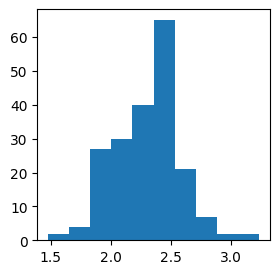

In [9]:
plt.figure(figsize=(3,3))
plt.hist(erypro_df["tpo_[ng_ml]"])
plt.show()

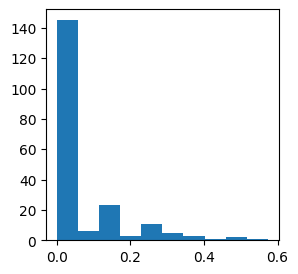

In [10]:
plt.figure(figsize=(3,3))
plt.hist(erypro_df["butyzamide_[nm]"])
plt.show()

EryPro has mostly TPO different from 0, butyazemide is basically zero

In [11]:
converted_erypro = conversion(erypro_df, "tpo_to_buty")

In [12]:
converted_erypro = np.log1p(converted_erypro)
erypro_df = np.log1p(erypro_df.loc[:, protocol_cols])

In [13]:
erypro_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
40,2.403327,1.213584,5.960538,1.177460,0.001871,0.000000,0.000000,0.271366,0.0,0.368369,2.720274,2.601578
39,2.436255,1.318517,5.463723,0.588389,0.000000,0.845548,0.000000,0.000000,0.0,0.000000,2.417726,2.906711
91,2.317950,1.148045,5.573439,0.589060,0.026380,0.867452,0.000000,0.412062,0.0,0.181250,2.639488,2.848482
84,2.312938,1.217910,6.244116,1.722375,0.128090,0.000000,0.000000,0.000000,0.0,0.085210,2.627209,2.827467
46,2.380004,1.278441,6.050249,1.119771,0.032594,0.192854,0.000000,0.514094,0.0,0.000000,2.620721,2.807570
...,...,...,...,...,...,...,...,...,...,...,...,...
34,2.413805,1.228271,3.920576,0.000000,0.000000,3.697916,0.037553,0.393361,0.0,0.031296,2.665689,2.950645
82,2.633384,1.171337,4.307015,0.061393,0.016069,3.779322,0.208296,0.442833,0.0,0.362789,2.673843,2.909251
34,2.413818,1.227532,3.916808,0.000000,0.000000,3.703489,0.037046,0.396068,0.0,0.031358,2.669809,2.950572
34,2.286551,1.251311,6.603115,3.630239,0.007441,1.035412,0.000000,0.486497,0.0,0.506310,2.825208,2.620206


In [14]:
converted_erypro

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
40,2.403327,0.0,5.960538,1.177460,0.001871,0.000000,0.118114,0.271366,0.0,0.368369,2.720274,2.601578
39,2.436255,0.0,5.463723,0.588389,0.000000,0.845548,0.135498,0.000000,0.0,0.000000,2.417726,2.906711
91,2.317950,0.0,5.573439,0.589060,0.026380,0.867452,0.108009,0.412062,0.0,0.181250,2.639488,2.848482
84,2.312938,0.0,6.244116,1.722375,0.128090,0.000000,0.118801,0.000000,0.0,0.085210,2.627209,2.827467
46,2.380004,0.0,6.050249,1.119771,0.032594,0.192854,0.128679,0.514094,0.0,0.000000,2.620721,2.807570
...,...,...,...,...,...,...,...,...,...,...,...,...
34,2.413805,0.0,3.920576,0.000000,0.000000,3.697916,0.120457,0.393361,0.0,0.031296,2.665689,2.950645
82,2.633384,0.0,4.307015,0.061393,0.016069,3.779322,0.111536,0.442833,0.0,0.362789,2.673843,2.909251
34,2.413818,0.0,3.916808,0.000000,0.000000,3.703489,0.120338,0.396068,0.0,0.031358,2.669809,2.950572
34,2.286551,0.0,6.603115,3.630239,0.007441,1.035412,0.124190,0.486497,0.0,0.506310,2.825208,2.620206


## Conversions late_MgkPro

In [15]:
MgkPro_df = generated_csvs["MgkPro"].loc[:, protocol_cols]

In [16]:
# Some solutions require a conversion, some others require another 
MgkPro_df["buty_to_tpo"] = False 

In [17]:
MgkPro_df.loc[MgkPro_df["tpo_[ng_ml]"] < 0.1, "buty_to_tpo"] = True

In [18]:
MgkPro_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,buty_to_tpo
67,0.000000,0.000000,0.000000,66.515010,0.000000,0.000000,110.476974,0.000000,0.000000,0.000000,19.016068,13.254240,True
67,0.000000,0.000000,0.000000,66.178680,0.000000,0.000000,110.445885,0.000000,0.000000,0.000000,18.985062,13.272754,True
17,0.477673,0.053988,0.049927,60.553190,0.000000,0.469665,87.517780,0.000000,0.000000,0.000000,17.692993,12.970562,True
19,0.000000,0.000000,0.198734,58.962450,0.000000,0.000000,104.683525,0.039752,0.025231,0.000000,18.468860,13.129865,True
67,0.000000,0.000000,0.000000,66.541990,0.000000,0.000000,110.506004,0.000000,0.000000,0.000000,19.036990,13.244378,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,6.831164,0.540616,21.223389,0.247175,0.009309,50.455860,5.685252,1.168162,0.003296,0.006617,9.648346,16.841585,False
12,6.826084,0.554899,21.969181,0.264390,0.000000,50.360320,5.633099,1.206609,0.000000,0.001705,9.731386,16.983692,False
17,7.173871,0.673145,12.685352,0.591284,0.000000,50.029873,4.404321,0.479312,0.003952,0.011884,10.358403,17.558767,False
12,5.939323,0.440202,12.451098,0.000000,0.000984,47.128933,5.029906,1.267006,0.000000,0.000000,9.256013,14.535924,False


In [19]:
MgkPro_df_buty_to_tpo = MgkPro_df[MgkPro_df["buty_to_tpo"]]

In [20]:
MgkPro_df_tpo_to_buty = MgkPro_df[~MgkPro_df["buty_to_tpo"]]

In [21]:
MgkPro_df_buty_to_tpo_converted = conversion(MgkPro_df_buty_to_tpo, "buty_to_tpo")

In [22]:
MgkPro_df_tpo_to_buty_converted = conversion(MgkPro_df_tpo_to_buty, "tpo_to_buty")

In [23]:
converted_mgkpro = pd.concat([MgkPro_df_buty_to_tpo_converted, 
                                  MgkPro_df_tpo_to_buty_converted]).drop(["buty_to_tpo"], axis=1)

converted_mgkpro

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
67,0.000000,2084.700499,0.000000,66.515010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.016068,13.254240
67,0.000000,2084.113850,0.000000,66.178680,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.985062,13.272754
17,0.477673,1651.460509,0.049927,60.553190,0.000000,0.469665,0.000000,0.000000,0.000000,0.000000,17.692993,12.970562
19,0.000000,1975.378117,0.198734,58.962450,0.000000,0.000000,0.000000,0.039752,0.025231,0.000000,18.468860,13.129865
67,0.000000,2085.248295,0.000000,66.541990,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.036990,13.244378
...,...,...,...,...,...,...,...,...,...,...,...,...
12,6.831164,0.000000,21.223389,0.247175,0.009309,50.455860,0.028653,1.168162,0.003296,0.006617,9.648346,16.841585
12,6.826084,0.000000,21.969181,0.264390,0.000000,50.360320,0.029410,1.206609,0.000000,0.001705,9.731386,16.983692
17,7.173871,0.000000,12.685352,0.591284,0.000000,50.029873,0.035677,0.479312,0.003952,0.011884,10.358403,17.558767
12,5.939323,0.000000,12.451098,0.000000,0.000984,47.128933,0.023331,1.267006,0.000000,0.000000,9.256013,14.535924


In [24]:
converted_mgkpro = np.log1p(converted_mgkpro)
MgkPro_df = np.log1p(MgkPro_df.loc[:, protocol_cols])

## Run predictions 

In [25]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"

from hydra import initialize, compose
import os
import sys
import logging
from sc_exp_design.constants import DataFields
import torch.nn.functional as F


sys.path.insert(0, os.path.join(BASE_DIR, "shared_utils"))

from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn, 
    compute_exploitation_score, 
    compute_exploration_score, 
    compute_weighted_uncertainty_score, 
    compute_sequential_local_penalization
)

Load models 

In [26]:
CONFIG_PATH = "../../../config"

with initialize(config_path=CONFIG_PATH, version_base=None):
    base_cfg = compose(
        config_name="run_inverse",
        overrides=["paths=bloodplus_fm"]
    )

In [27]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [28]:
base_cfg["paths"]

{'perturbation_prediction_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl', 'ct_classifier_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/easy-monkey-341_TargetPredictionModel.pkl', 'prior_flow_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-04-04_10-19-42/woven-dawn-22_FlowMatchingWithScore.pkl', 'prior_flow_map_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_map/2026-04-13_11-57-30/copper-thunder-24_FlowMap.pkl', 'dump_dir': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse'}

In [29]:
forward_model, (_, target_prediction_model) = get_forward_model(base_cfg, logger=logger)

2026-04-30 09:10:37,047 - INFO - Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
2026-04-30 09:12:26,950 - INFO - Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
   

Prepare label encoder for plots 

In [30]:
# Prepare label encoder
logger.info("Preparing labels")   
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 

2026-04-30 09:12:28,458 - INFO - Preparing labels


In [31]:
labels_conversion = ["after conversion", "before conversion",]

## Predict EryPro

In [44]:
n_noise_samples = 1000

In [45]:
pred_df_erypro = []

with torch.no_grad():
    for label_converson, df in zip(labels_conversion, [erypro_df, converted_erypro]):
        # Get candidates 
        X_candidates =  torch.from_numpy(
            df.values
        ).float().to(
            forward_model.forward_model.device
        )
        # Predict 
        X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
        condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
        batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}
        forward_out = forward_model.predict(
            batch_dict,
            no_grad=True,
            fix_noise=False,
            num_time_steps=100
        )

        y_pred = F.softmax(forward_out["target_prediction_data"]["cell_type"], dim=-1).mean(1)
        pred_df = pd.DataFrame(y_pred.cpu().numpy(), columns=classes)
        pred_df_erypro.append(pred_df)

In [46]:
pred_df_erypro = [df.melt() for df in pred_df_erypro]
pred_df_erypro[1]["dataset_type"] = "Convert TPO to butyzamide"
pred_df_erypro[0]["dataset_type"] = "Original generated"

pred_df_erypro = pd.concat(pred_df_erypro)

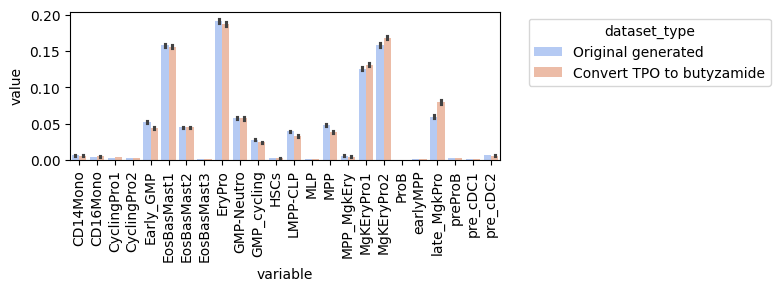

In [53]:
plt.figure(figsize=(8,3))
ax = sns.barplot(
    data=pred_df_erypro,
    x="variable",
    y="value",
    hue="dataset_type",
    palette="coolwarm"
)

plt.xticks(rotation=90)

# Place legend outside
ax.legend(title="dataset_type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## Predict MgkPro

In [36]:
pred_df_MgkPro = []

with torch.no_grad():
    for label_converson, df in zip(labels_conversion, [converted_mgkpro, MgkPro_df]):
        # Get candidates 
        X_candidates =  torch.from_numpy(
            df.values
        ).float().to(
            forward_model.forward_model.device
        )
        # Predict 
        X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
        condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
        batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}
        forward_out = forward_model.predict(
            batch_dict,
            no_grad=True,
            fix_noise=False,
            num_time_steps=100
        )

        y_pred = F.softmax(forward_out["target_prediction_data"]["cell_type"], dim=-1).mean(1)
        pred_df = pd.DataFrame(y_pred.cpu().numpy(), columns=classes)
        pred_df_MgkPro.append(pred_df)

In [37]:
pred_df_MgkPro = [df.melt() for df in pred_df_MgkPro]
pred_df_MgkPro[0]["dataset_type"] = "After conversion"
pred_df_MgkPro[1]["dataset_type"] = "Before conversion"

pred_df_MgkPro = pd.concat(pred_df_MgkPro)

In [54]:
# sns.barplot(data=pred_df_MgkPro, x="variable", y="value", hue="dataset_type")

# plt.xticks(rotation=90)  # rotate labels (e.g., 45 degrees)
# plt.tight_layout()       # prevent cutoff
# plt.show()